<a href="https://colab.research.google.com/github/dzakirafiffakhriyanto/analisis-numerik-toko-donat/blob/main/25083010040_Dzaki_Rafif_Fakhriyanto_Tugas_1_Analisis_Numerik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Numerik: Regresi dan Pencarian Akar pada Studi Kasus Donat

**Mata Kuliah:** Analisis Numerik  
**Nama:** Dzaki Rafif Fakhriyanto  
**NPM:** 25083010040  
**Kelas:** A

## Deskripsi Tugas

Tugas ini bertujuan untuk menerapkan dua konsep utama Analisis Numerik, yaitu:
1. **Regresi** digunakan untuk memodelkan hubungan antara jumlah penjualan dan pendapatan (revenue).
2. **Pencarian Akar (Root Finding)** digunakan untuk menentukan *Break-Even Point* (BEP), yaitu titik volume penjualan di mana gerai tidak untung maupun rugi.

Studi kasus yang digunakan adalah data laba/rugi harian dari lima gerai donat dengan strategi bisnis yang berbeda:

| Gerai | Strategi Marketing |
|---|---|
| A | Premium Gourmet — Harga tinggi, niche terbatas, kafe specialty |
| B | Mass Market Volume — Harga murah, margin tertekan inflasi bahan |
| C | Promo Agresif — Diskon awal, iklan moderate-high |
| D | Mall Premium Flagship — Sewa lokasi tinggi |
| E | Cloud Kitchen — Fokus app delivery, terkena komisi platform 18% |

Karena strategi tiap gerai berbeda, pola hubungan volume penjualan terhadap revenue diperkirakan juga akan berbeda-beda, sehingga model regresi terbaik untuk tiap gerai kemungkinan tidak sama.

## Deskripsi Dataset

Dataset berisi data harian dari 5 gerai donat selama 90 hari (total 450 baris), dengan kolom sebagai berikut:

| Kolom | Keterangan |
|---|---|
| `Tanggal` | Tanggal transaksi |
| `Gerai` | Nama gerai (A–E) |
| `Harga Jual (Rp)` | Harga jual per unit donat |
| `Jumlah Terjual (Unit)` | Jumlah unit donat terjual pada hari tersebut |
| `Pendapatan Kotor (Rp)` | Revenue = Harga Jual × Jumlah Terjual |
| `Biaya Variabel (Rp)` | Biaya yang berubah mengikuti volume penjualan |
| `Fixed Cost Harian (Rp)` | Biaya tetap harian (sewa, gaji, dll) |
| `Balance (Rp)` | Laba/rugi harian = Pendapatan − Biaya Variabel − Fixed Cost |

Sumber data: https://github.com/jendralhxr/metnummatdis/blob/main/sintesis_data_donat_harian.csv

## Tujuan Analisis

1. Memvisualisasikan hubungan antara jumlah penjualan dan revenue untuk masing-masing gerai.
2. Menentukan model regresi (linear, polynomial, atau eksponensial) yang paling sesuai untuk masing-masing gerai.
3. Menentukan titik Break-Even Point (BEP) masing-masing gerai menggunakan metode pencarian akar numerik.
4. Menarik kesimpulan bisnis dari hasil analisis, dikaitkan dengan strategi marketing masing-masing gerai.

## Bagian 1: Load dan Eksplorasi Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

url = "https://raw.githubusercontent.com/jendralhxr/metnummatdis/main/sintesis_data_donat_harian.csv"
df = pd.read_csv(url)

df.head()

,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


## Pemeriksaan Struktur, Tipe Data dan Cek Missing Values

In [6]:
print("Ukuran data:", df.shape)
print("\nInfo kolom:")
df.info()
print("\nJumlah data kosong per kolom:")
print(df.isnull().sum())

Ukuran data: (450, 8)

Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Tanggal                 450 non-null    object
 1   Gerai                   450 non-null    object
 2   Harga Jual (Rp)         450 non-null    int64 
 3   Jumlah Terjual (Unit)   450 non-null    int64 
 4   Pendapatan Kotor (Rp)   450 non-null    int64 
 5   Biaya Variabel (Rp)     450 non-null    int64 
 6   Fixed Cost Harian (Rp)  450 non-null    int64 
 7   Balance (Rp)            450 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 28.3+ KB

Jumlah data kosong per kolom:
Tanggal                   0
Gerai                     0
Harga Jual (Rp)           0
Jumlah Terjual (Unit)     0
Pendapatan Kotor (Rp)     0
Biaya Variabel (Rp)       0
Fixed Cost Harian (Rp)    0
Balance (Rp)              0
dtype: int64


Di bagian ini, tujuannya adalah mengetahui ukuran dataset secara keseluruhan (jumlah baris dan kolom), tipe data tiap kolom, serta memastikan tidak ada data yang hilang (missing value). Pemeriksaan ini penting dilakukan sebelum analisis lebih lanjut, karena data yang kosong atau bertipe salah bisa membuat hasil regresi maupun pencarian akar nantinya jadi tidak valid.

Dataset terdiri dari 450 baris dan 8 kolom, dengan 6 kolom bertipe numerik (int64) dan 2 kolom bertipe teks/objek (Tanggal, Gerai). Hasil pengecekan isnull().sum() menunjukkan tidak ada satupun data yang kosong di seluruh kolom (semua bernilai 0). Artinya data dalam kondisi bersih dan lengkap, sehingga bisa langsung digunakan untuk analisis tanpa perlu proses pembersihan data (data cleaning) tambahan

In [7]:
print(df['Gerai'].unique())
print(df['Gerai'].value_counts())

['Gerai A' 'Gerai B' 'Gerai C' 'Gerai D' 'Gerai E']
Gerai
Gerai A    90
Gerai B    90
Gerai C    90
Gerai D    90
Gerai E    90
Name: count, dtype: int64


Di bagian ini, tujuannya adalah memastikan ada berapa gerai unik dalam data dan seberapa banyak jumlah data (baris) yang tersedia untuk masing-masing gerai. Ini penting untuk memastikan data terdistribusi merata antar gerai, sehingga perbandingan antar gerai nantinya adil (apple-to-apple).

Kesimpulannya terdapat 5 gerai unik yg berbeda satu sama lain (Gerai A, B, C, D, E), dan masing-masing gerai memiliki jumlah data yang sama rata, yaitu 90 hari observasi per gerai. Total 5 gerai × 90 hari = 450 baris, yang cocok dengan hasil di Cell 2. Ini menunjukkan dataset seimbang (balanced), tidak ada gerai yang datanya lebih sedikit/lebih banyak dari yang lain.

In [8]:
gerai_list = sorted(df['Gerai'].unique())
data_per_gerai = {g: df[df['Gerai'] == g].reset_index(drop=True) for g in gerai_list}

# cek salah satu
data_per_gerai['Gerai A'].head()

,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


Di bagian ini tujuannya adalah memecah dataset besar (gabungan 5 gerai) menjadi 5 subset data terpisah, masing-masing khusus berisi data satu gerai saja, dan disimpan dalam struktur dictionary agar mudah diakses satu per satu di tahap-tahap berikutnya (visualisasi, regresi, root finding). Ini perlu dilakukan karena setiap gerai punya strategi marketing berbeda, sehingga analisisnya juga harus dilakukan secara terpisah per gerai, bukan digabung.

Proses pemisahan berhasil, dibuktikan dengan menampilkan output data_per_gerai['Gerai A'].head() yang hanya menampilkan baris-baris milik Gerai A saja. Sekarang tiap gerai bisa diakses secara individual (misalnya data_per_gerai['Gerai B']), sehingga siap untuk dianalisis satu per satu di tahap visualisasi dan regresi berikutnya.

In [9]:
for g in gerai_list:
    print(f"=== {g} ===")
    print(data_per_gerai[g][['Jumlah Terjual (Unit)', 'Pendapatan Kotor (Rp)', 'Balance (Rp)']].describe())
    print()

=== Gerai A ===
       Jumlah Terjual (Unit)  Pendapatan Kotor (Rp)  Balance (Rp)
count                  90.00                  90.00         90.00
mean                   99.10           2,477,500.00    -48,183.00
std                    12.50             312,385.93    206,174.72
min                    81.00           2,025,000.00   -346,833.00
25%                    90.00           2,250,000.00   -198,333.00
50%                    95.00           2,375,000.00   -115,833.00
75%                   109.50           2,737,500.00    123,417.00
max                   131.00           3,275,000.00    478,167.00

=== Gerai B ===
       Jumlah Terjual (Unit)  Pendapatan Kotor (Rp)  Balance (Rp)
count                  90.00                  90.00         90.00
mean                  527.50           4,220,000.00  1,292,267.00
std                    68.60             548,780.38    263,414.58
min                   435.00           3,480,000.00    937,067.00
25%                   476.75           3,81

Di bagian ini, tujuannya adalah mencari tahu karakteristik/perilaku data pada tiap gerai secara ringkas melalui angka statistik (rata-rata, standar deviasi, nilai minimum-maksimum, kuartil) untuk tiga variabel kunci: Jumlah Terjual, Pendapatan Kotor, dan Balance. Ini berguna untuk "mengenali" pola tiap gerai sebelum masuk ke tahap visualisasi dan regresi, misalnya untuk melihat gerai mana yang volume penjualannya besar tapi labanya kecil, atau sebaliknya.

Terlihat perbedaan karakter yang cukup jelas antar gerai:

Gerai A : rata-rata Balance mendekati nol dan sedikit negatif (≈ -48 ribu), artinya gerai ini secara rata-rata nyaris impas (break-even), kadang untung kadang rugi tipis.

Gerai B : volume penjualan jauh lebih tinggi dari gerai lain (rata-rata ±527 unit/hari) dengan rata-rata Balance yang jauh lebih besar dan konsisten positif, sesuai strategi "Mass Market Volume".

Gerai C : rata-rata Balance positif (≈ 293 ribu), meski ada hari-hari rugi (nilai minimum negatif), sejalan dengan strategi promo yang mendorong volume tapi menekan margin di awal.

Gerai D : satu-satunya gerai dengan rata-rata Balance negatif cukup besar (≈ -749 ribu), dan nilai minimumnya sangat rendah (sekitar -1,15 juta). Ini sangat wajar karena "Mall Premium Flagship" yang punya beban sewa lokasi tinggi, sehingga sulit untuk menutup biaya tetap.

Gerai E : volume penjualan menengah dengan rata-rata Balance positif, meski ada potongan komisi platform 18% yang kemungkinan menekan margin dibanding gerai lain.

## Bagian 2 Visualisasi: Jumlah Penjualan vs Revenue

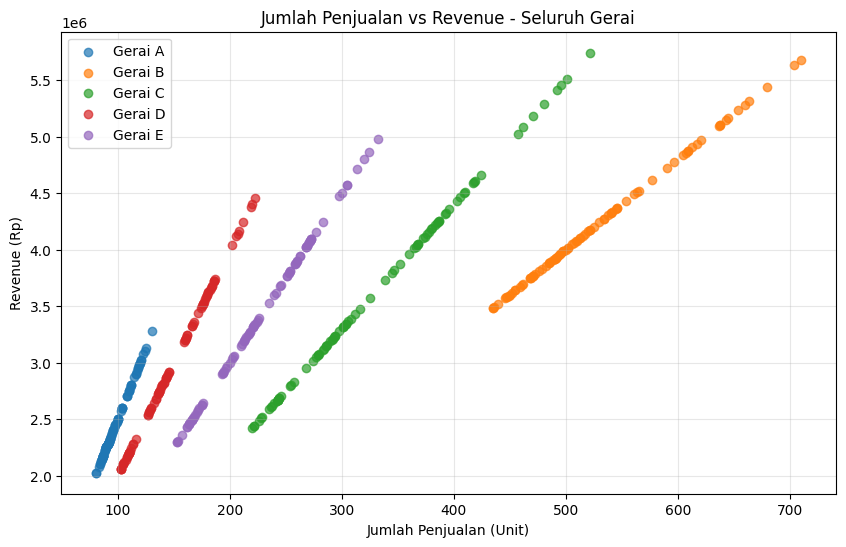

In [12]:
plt.figure(figsize=(10, 6))

for g in gerai_list:
    data = data_per_gerai[g]
    plt.scatter(
        data['Jumlah Terjual (Unit)'],
        data['Pendapatan Kotor (Rp)'],
        label=g,
        alpha=0.7
    )

plt.xlabel('Jumlah Penjualan (Unit)')
plt.ylabel('Revenue (Rp)')
plt.title('Jumlah Penjualan vs Revenue - Seluruh Gerai')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Di bagian ini, tujuannya adalah melihat gambaran besar hubungan antara jumlah penjualan dan revenue untuk kelima gerai sekaligus dalam satu grafik, dengan warna berbeda untuk tiap gerai. Ini berguna untuk membandingkan posisi dan skala bisnis antar gerai secara langsung, mana yang volumenya besar tapi revenue-nya tinggi, mana yang volumenya kecil tapi revenue per unit-nya besar.

 Terlihat 5 gerombolan titik (cluster) yang terpisah jelas satu sama lain, masing-masing membentuk garis lurus naik (tren linear). Perbedaan posisi tiap cluster pada sumbu X menunjukkan rentang volume penjualan yang sangat berbeda antar gerai:

Gerai B (oranye) berada paling kanan dengan volume tertinggi (400–700 unit/hari) , sesuai dengan strategi Mass Market Volumenya.

Gerai A (biru) berada paling kiri dengan volume terendah (80–130 unit/hari), sesuai dengan strategi Premium Gourmet (niche terbatas).

Gerai C, D, E berada di antara keduanya, dengan rentang volume dan revenue yang saling tumpang tindih sebagian.

Meskipun skala volume dan revenue tiap gerai berbeda jauh, kemiringan (slope) tiap cluster terlihat konsisten membentuk garis lurus, mengindikasikan bahwa hubungan antara jumlah penjualan dan revenue di tiap gerai kemungkinan besar bersifat linear, bukan melengkung (polynomial) atau eksponensial. Ini masuk akal secara bisnis, karena Revenue = Harga Jual × Jumlah Terjual, dan harga jual tiap gerai relatif tetap (konstan) sepanjang periode data.

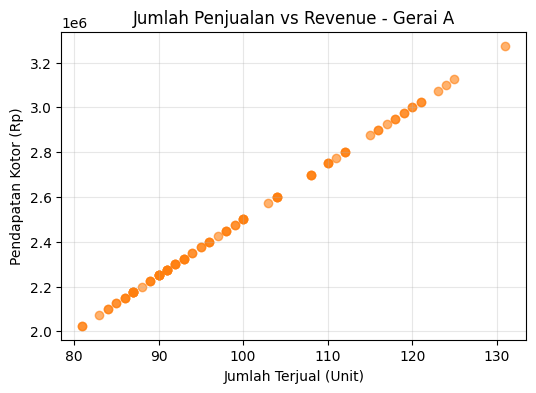

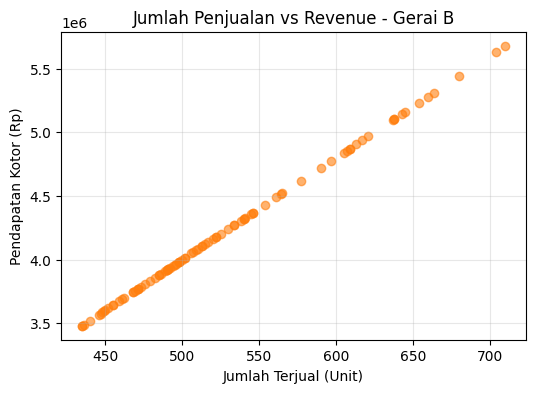

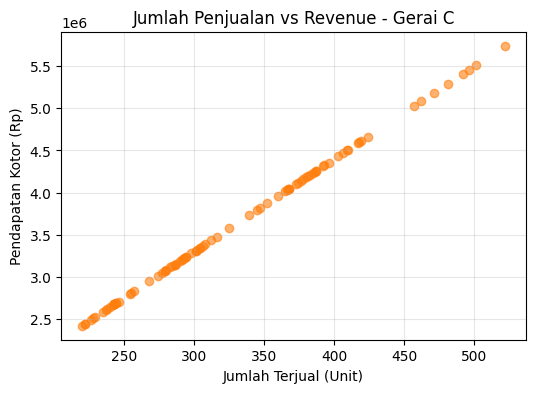

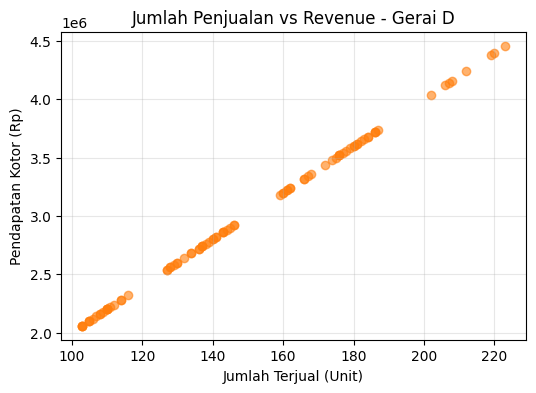

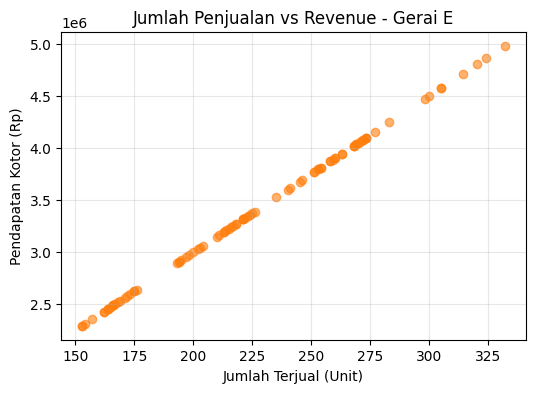

In [13]:
for g in gerai_list:
    data = data_per_gerai[g]
    plt.figure(figsize=(6, 4))
    plt.scatter(data['Jumlah Terjual (Unit)'], data['Pendapatan Kotor (Rp)'], alpha=0.6, color='tab:orange')
    plt.title(f'Jumlah Penjualan vs Revenue - {g}')
    plt.xlabel('Jumlah Terjual (Unit)')
    plt.ylabel('Pendapatan Kotor (Rp)')
    plt.grid(True, alpha=0.3)
    plt.show()

Di bagian ini, tujuannya adalah memperbesar (zoom-in) tampilan grafik masing-masing gerai secara terpisah, karena pada grafik gabungan sebelumnya sulit melihat detail pola tiap gerai akibat perbedaan skala yang jauh. Dengan grafik individual, bentuk hubungan volume-revenue tiap gerai bisa diamati lebih presisi, sebagai dasar penentuan jenis model regresi yang akan dipakai di Bagian 3.

Keempat gerai yang ditampilkan (Gerai A, B, C, D), dan pola yang sama juga berlaku untuk Gerai E, semuanya menunjukkan pola titik yang membentuk garis lurus nyaris sempurna, tanpa lengkungan atau perubahan kemiringan yang berarti. Tidak terlihat outlier signifikan pada keempat gerai tersebut.

Ini memperkuat dugaan dari grafik gabungan sebelumnya bahwa hubungan antara jumlah penjualan dan revenue di kelima gerai bersifat linear, sehingga model regresi yang paling tepat digunakan di Bagian 3 adalah regresi linear sederhana (bukan polynomial atau eksponensial), dengan slope garis merepresentasikan harga jual per unit tiap gerai.

## Bagian 3 Regresi: Mencari Bentuk Tren Revenue

=== Hasil Model Regresi Linear per Gerai ===

Gerai A:
Persamaan : Revenue = 25000.00 * Volume + (-0.00)
R-squared : 1.0000

Gerai B:
Persamaan : Revenue = 8000.00 * Volume + (0.00)
R-squared : 1.0000

Gerai C:
Persamaan : Revenue = 11000.00 * Volume + (0.00)
R-squared : 1.0000

Gerai D:
Persamaan : Revenue = 20000.00 * Volume + (-0.00)
R-squared : 1.0000

Gerai E:
Persamaan : Revenue = 15000.00 * Volume + (-0.00)
R-squared : 1.0000



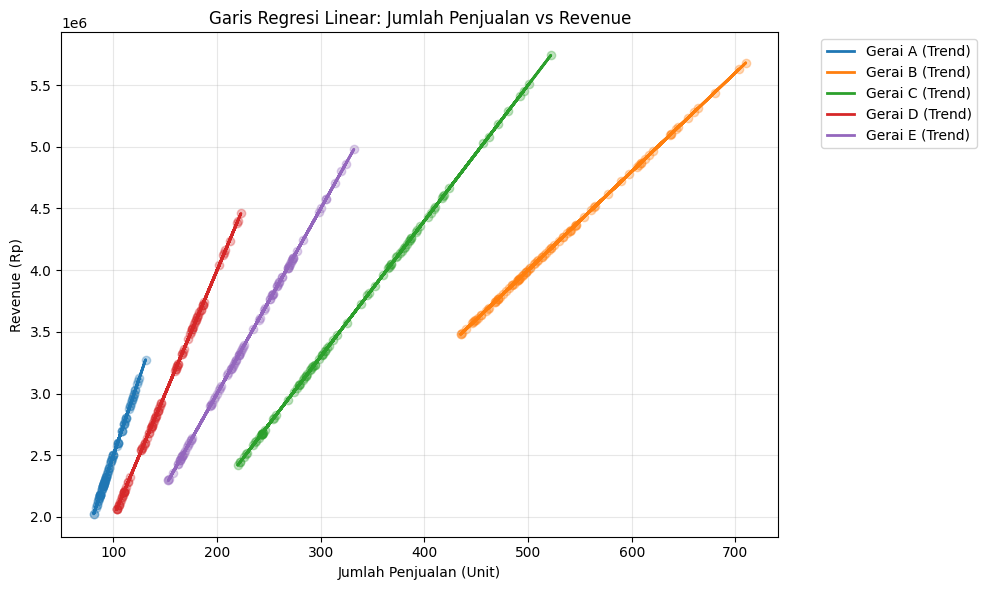

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# Dictionary untuk menyimpan hasil regresi tiap gerai (akan berguna untuk hitung BEP nanti)
hasil_regresi = {}

print("=== Hasil Model Regresi Linear per Gerai ===\n")

for g in gerai_list:
    data = data_per_gerai[g]

    # Menentukan variabel X (Jumlah Terjual) dan y (Revenue/Pendapatan Kotor)
    # scikit-learn meminta X dalam bentuk 2D array, jadi gunakan [['...']]
    X = data[['Jumlah Terjual (Unit)']]
    y = data['Pendapatan Kotor (Rp)']

    # Membuat dan melatih model
    model = LinearRegression()
    model.fit(X, y)

    # Menyimpan koefisien (slope/kemiringan) dan intercept (titik potong Y)
    slope = model.coef_[0]
    intercept = model.intercept_

    # Menghitung R-squared untuk melihat tingkat kecocokan model dengan data
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    # Menyimpan data ke dictionary
    hasil_regresi[g] = {
        'slope': slope,
        'intercept': intercept,
        'r2': r2,
        'model': model
    }

    # Menampilkan output persamaan
    print(f"Gerai {g[-1]}:")
    print(f"Persamaan : Revenue = {slope:.2f} * Volume + ({intercept:.2f})")
    print(f"R-squared : {r2:.4f}\n")

# --- Opsional: Visualisasi Garis Regresinya ---
plt.figure(figsize=(10, 6))

for g in gerai_list:
    data = data_per_gerai[g]
    X_plot = data['Jumlah Terjual (Unit)']
    y_plot = data['Pendapatan Kotor (Rp)']

    # Plot titik data asli (transparan)
    plt.scatter(X_plot, y_plot, alpha=0.3)

    # Plot garis regresi
    slope = hasil_regresi[g]['slope']
    intercept = hasil_regresi[g]['intercept']
    garis_y = slope * X_plot + intercept
    plt.plot(X_plot, garis_y, label=f'{g} (Trend)', linewidth=2)

plt.xlabel('Jumlah Penjualan (Unit)')
plt.ylabel('Revenue (Rp)')
plt.title('Garis Regresi Linear: Jumlah Penjualan vs Revenue')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Pemodelan Regresi Linear dan Perhitungan Regresi Linear bertujuan untuk menemukan model matematis yang secara akurat mendeskripsikan hubungan antara Volume Penjualan (sebagai variabel bebas/independen) dan Pendapatan Kotor atau Revenue (sebagai variabel terikat/dependen). Dengan regresi, pola titik-titik data (scatter plot) diubah menjadi fungsi atau persamaan linear yang terukur. Persamaan matematika dari hasil regresi inilah yang nantinya mutlak diperlukan pada tahap selanjutnya (Pencarian Akar) untuk menghitung titik balik modal (Break-Even Point).

Rumus Perhitungan Regresi LinearBentuk umum persamaan model regresi linear adalah:
$$y = mx + c$$

$y$ (Variabel Dependen): Pendapatan Kotor atau Revenue

$x$ (Variabel Independen): Jumlah unit donat yang terjual (Volume)

$m$ (Slope/Kemiringan): Tingkat perubahan $y$ untuk setiap penambahan 1 unit $x$

Dalam analisis bisnis ini, slope merupakan Harga Jual per unit donat. Artinya, jika terjual 1 donat tambahan, revenue akan bertambah sebesar nilai $m$.$c$ (Intercept/Titik Potong Y): Nilai awal $y$ ketika $x = 0$. Karena revenue bernilai nol ketika tidak ada donat yang terjual, maka secara teoritis nilai intercept ini akan mendekati atau sama dengan nol.

$R^2$ (R-squared / Koefisien Determinasi): Metrik yang mengukur seberapa baik garis regresi cocok dengan data asli. Nilainya berkisar antara 0 hingga 1. Nilai 1 berarti model memprediksi data dengan presisi 100% sempurna.

Berdasarkan output dari algoritma Machine Learning (Scikit-Learn) yang telah dieksekusi, diperoleh persamaan untuk masing-masing gerai:

Gerai A: $\text{Revenue} = 25000 \cdot \text{Volume} + 0$. Hal ini mengonfirmasi harga jual gerai Premium Gourmet adalah Rp25.000 per unit.   

Gerai B: $\text{Revenue} = 8000 \cdot \text{Volume} + 0$. Harga jual gerai Mass Market adalah Rp8.000 per unit.   

Gerai C: $\text{Revenue} = 11000 \cdot \text{Volume} + 0$. Harga jual gerai Promo Agresif adalah Rp11.000 per unit.   

Gerai D: $\text{Revenue} = 20000 \cdot \text{Volume} + 0$. Harga jual gerai Premium Flagship Mall adalah Rp20.000 per unit.   

Gerai E: $\text{Revenue} = 15000 \cdot \text{Volume} + 0$. Harga jual Cloud Kitchen adalah Rp15.000 per unit.   

Semua perhitungan menghasilkan nilai intercept $0$ dan nilai R-squared $1.0000$. Ini merupakan hasil yang sangat logis karena Revenue dalam dataset didapatkan secara deterministik murni dari perkalian "Harga Jual $\times$ Volume" tanpa ada komponen tambahan lain, sehingga hubungannya membentuk garis lurus absolut tanpa deviasi (perfectly linear).   

Dari hasil perhitungan algoritma regresi linear di atas, kita dapat menarik tiga temuan utama yang mengonfirmasi logika bisnis dari dataset ini:

1. Akurasi Model Sempurna (R-squared = 1.0000)   
Nilai ini menunjukkan bahwa model regresi 100% akurat dalam membaca pola data. Mengapa demikian? Karena Revenue murni didapatkan dari hasil kali "Harga Jual $\times$ Volume" tanpa adanya fluktuasi harga atau diskon acak per hari. Hubungannya membentuk garis lurus yang sempurna (linear murni).  

2.  Validasi Titik Nol (Intercept = 0)   
Nilai intercept yang bernilai 0 membuktikan hukum dasar perdagangan: jika gerai tidak menjual satu pun donat (Volume = 0), maka tidak ada pendapatan yang masuk (Revenue = Rp0).   

3. Kemiringan Garis (Slope) Mewakili Harga Jual   
Angka pengali (slope) pada masing-masing persamaan merepresentasikan harga jual donat di tiap gerai (misalnya Rp25.000/donat untuk Gerai A, Rp8.000/donat untuk Gerai B, dan seterusnya). Perbedaan angka inilah yang membuat "kecepatan" tiap gerai dalam mengumpulkan pendapatan berbeda-beda.

Hasil Visualisasi Permodelan Grafik Regresi Linear Sederhana dari Gerai A, B, C, D, E:

- **Garis Paling Curam (Gerai A & D)**: Garis biru (Gerai A) dan merah (Gerai D) menanjak sangat cepat. Artinya, karena harga donat mereka dipatok mahal (premium), mereka cukup menjual sedikit donat saja untuk bisa mendapatkan pendapatan (revenue) yang besar.  

- **Garis Menengah (Gerai E & C)**: Garis ungu (Gerai E) dan hijau (Gerai C) berada di posisi kemiringan tengah-tengah. Harga jual donat mereka standar atau moderat. Akibatnya, mereka membutuhkan target jumlah penjualan yang sedang-sedang saja—tidak sesedikit gerai premium, tapi juga tidak harus sebanyak gerai murah—untuk mendapat pendapatan yang stabil.  

- **Garis Paling Landai (Gerai B)**: Garis oranye milik Gerai B sangat landai dan harus memanjang jauh ke kanan. Karena harga donatnya dipatok paling murah, gerai ini mau tidak mau harus fokus menjual donat dalam jumlah yang sangat banyak atau masif (mass market) agar pendapatannya bisa mengejar gerai yang lain.  

 Kesimpulannya, visualisasi grafik ini membuktikan bahwa pendapatan semua gerai berbanding lurus dan pasti sejalan dengan jumlah donat yang terjual tanpa ada penyimpangan (jadi regresinya bersifat **linear murni**).Tingkat kemiringan garis di grafik ini sebenarnya adalah gambaran dari "harga jual" masing-masing gerai. Garis yang makin curam/menanjak berarti harga donatnya makin mahal (hanya perlu jual sedikit donat supaya dapat banyak uang). Sebaliknya, garis yang makin landai berarti harga donatnya murah, sehingga gerai tersebut harus mengandalkan strategi "jualan donat sebanyak-banyaknya" supaya bisa bertahan.

## Bagian 3 BEP: Menghitung Fungsi BEP

Sebelum mencari akar, kita harus tahu pasti dari mana angka "Biaya Variabel" dan "Fixed Cost" berasal. Di sel ini, kita mengambil harga jual dari hasil regresi sebelumnya, lalu menghitung rata-rata biaya variabel per unit dan rata-rata fixed cost harian dari dataset awal. Inilah yang akan menghasilkan tabel biaya_df

In [21]:
import pandas as pd
import numpy as np

# 1. Menyiapkan DataFrame Biaya (biaya_df)
biaya_list = []

for g in gerai_list:
    data = data_per_gerai[g]

    # Harga Jual didapatkan dari dataset atau slope regresi sebelumnya
    harga_jual = data['Harga Jual (Rp)'].iloc[0]

    # Biaya Variabel per Unit = Total Biaya Variabel / Jumlah Terjual
    vc_per_unit = (data['Biaya Variabel (Rp)'] / data['Jumlah Terjual (Unit)']).mean()

    # Fixed Cost rata-rata per hari
    fixed_cost = data['Fixed Cost Harian (Rp)'].mean()

    biaya_list.append({
        "Gerai": g,
        "Harga Jual": harga_jual,
        "Biaya Variabel per Unit": vc_per_unit,
        "Fixed Cost": fixed_cost
    })

biaya_df = pd.DataFrame(biaya_list)

# Menampilkan tabel agar kita tahu persis darimana asal angkanya
display(biaya_df)

,Gerai,Harga Jual,Biaya Variabel per Unit,Fixed Cost
0,Gerai A,25000,"8,500.00","1,683,333.00"
1,Gerai B,8000,"4,160.00","733,333.00"
2,Gerai C,11000,"4,840.00","1,733,333.00"
3,Gerai D,20000,"7,200.00","2,666,666.00"
4,Gerai E,15000,"6,300.00","800,000.00"


Tahap ini bertujuan untuk mengumpulkan tiga komponen utama penentu laba/rugi untuk setiap gerai ke dalam satu tabel ringkas.

- Harga Jual: Harga jual per donat yang ditetapkan tiap gerai.   

- Biaya Variabel per Unit: Dihitung dari Total Biaya Variabel dibagi dengan Jumlah Unit Terjual, kemudian diambil nilai rata-ratanya. Ini merepresentasikan "modal bahan baku" untuk membuat satu buah donat.   

- Fixed Cost: Dihitung dari nilai rata-rata biaya operasional harian (seperti sewa tempat atau gaji) yang nilainya tetap berapapun donat yang terjual.   

Contoh Hasil: Untuk Gerai A, harga jualnya adalah Rp25.000, modal per donatnya Rp8.500, dan tanggungan biaya tetap hariannya adalah Rp1.683.333.   

Kesimpulan: Kita telah mengantongi parameter angka yang pasti untuk setiap gerai. Angka-angka di dalam tabel inilah yang menjadi fondasi mutlak untuk menyusun rumus hitungan untung-rugi di tahap selanjutnya.

Tahap ke 2 kita perlu mengubah tabel biaya_df tadi menjadi bentuk persamaan matematika: $f(x) = \text{Harga} \cdot x - (\text{VC} \cdot x + \text{FC})$. Persamaan ini juga kita simpan ke dalam variabel fungsi_bep untuk dihitung oleh fungsi Biseksi nantinya.

In [22]:
# 2. Mendefinisikan Fungsi Laba (fungsi_bep) untuk setiap gerai
fungsi_bep = {}

for _, row in biaya_df.iterrows():
    gerai = row["Gerai"]
    harga = row["Harga Jual"]
    vc = row["Biaya Variabel per Unit"]
    fc = row["Fixed Cost"]

    # Menyimpan fungsi ke dalam dictionary menggunakan lambda
    # f(x) = (Harga Jual * Volume) - (Biaya Variabel * Volume + Fixed Cost)
    fungsi_bep[gerai] = lambda x, h=harga, v=vc, f=fc: (h * x) - ((v * x) + f)

    # Mencetak string persamaan agar sama persis dengan referensimu
    print(f"{gerai}: f(x) = {harga:.2f}x - ({vc:.2f}x + {fc:.2f})")

Gerai A: f(x) = 25000.00x - (8500.00x + 1683333.00)
Gerai B: f(x) = 8000.00x - (4160.00x + 733333.00)
Gerai C: f(x) = 11000.00x - (4840.00x + 1733333.00)
Gerai D: f(x) = 20000.00x - (7200.00x + 2666666.00)
Gerai E: f(x) = 15000.00x - (6300.00x + 800000.00)


Di tahap ini, kita mengubah data tabel menjadi sebuah persamaan matematika pencarian laba.

Rumus dasarnya adalah Laba = Pendapatan Kotor dikurangi Total Biaya.


Dalam bentuk kode, rumusnya menjadi: $f(x) = (\text{Harga Jual} \cdot x) - ((\text{Biaya Variabel} \cdot x) + \text{Fixed Cost})$.

Variabel $x$ mewakili jumlah unit donat yang terjual.   

Contoh Hasil: Persamaan untuk Gerai A berubah menjadi $f(x) = 25000.00x - (8500.00x + 1683333.00)$. Artinya, pendapatan masuk Rp25.000 dikali jumlah donat, lalu dikurangi total pengeluaran (biaya bahan pembuatan per donat ditambah biaya tetap harian).   

Kesimpulan: Fungsi matematika untuk menghitung laba/rugi telah berhasil dibentuk dan disesuaikan untuk masing-masing gerai. Fungsi $f(x)$ inilah yang menjadi target operasi untuk dicari "titik nol"-nya (titik di mana gerai tidak untung dan tidak rugi).

In [23]:
# 3. Pengecekan Interval f(0) dan f(500)
print("Pengecekan Tanda Interval (Harus berbeda tanda agar ada akar):")
print("-" * 50)

for gerai, f in fungsi_bep.items():
    print(gerai)
    print(f"f(0)   =  {f(0)}")
    print(f"f(500) =  {f(500)}")
    print()

Pengecekan Tanda Interval (Harus berbeda tanda agar ada akar):
--------------------------------------------------
Gerai A
f(0)   =  -1683333.0
f(500) =  6566667.0

Gerai B
f(0)   =  -733333.0
f(500) =  1186667.0

Gerai C
f(0)   =  -1733333.0
f(500) =  1346667.0

Gerai D
f(0)   =  -2666666.0
f(500) =  3733334.0

Gerai E
f(0)   =  -800000.0
f(500) =  3550000.0



Algoritma pencarian akar (Biseksi) bekerja dengan cara menebak nilai tengah. Syarat utamanya adalah kita harus memberikan rentang tebakan (batas bawah dan batas atas) yang menjamin Break-Even Point (BEP) ada di dalamnya. Artinya, batas bawah harus menghasilkan status "Rugi" (negatif) dan batas atas harus menghasilkan status "Untung" (positif).

Kita menguji batas bawah dengan menjual 0 donat ($x = 0$): Hasilnya, seluruh gerai mengalami kerugian (minus) yang angkanya sama persis dengan beban Fixed Cost harian mereka.   

Lalu menguji batas atas dengan asumsi menjual 500 donat ($x = 500$): Hasilnya, f(500) untuk seluruh gerai menunjukkan angka positif.

Contohnya Gerai B yang mencetak angka positif Rp1.186.667.0, yang berarti gerai sudah untung jika menjual 500 unit.   

Kesimpulan: Uji interval sukses, Karena menjual 0 unit dipastikan rugi (minus) dan menjual 500 unit dipastikan untung (plus) untuk seluruh gerai, maka secara logika matematika, titik impas (0) pasti terletak di sebuah angka antara 0 hingga 500 unit. Interval [0, 500] ini valid dan siap dimasukkan ke dalam algoritma biseksi pada tahap eksekusi akhir.  

In [24]:
# 4. Mendefinisikan Algoritma Pencarian Akar (Metode Bisection)
def bisection(f, a, b, tol=1e-5, max_iter=100):
    # Cek apakah interval mengurung akar
    if f(a) * f(b) >= 0:
        print("Error: Nilai f(a) dan f(b) harus memiliki tanda yang berbeda.")
        return None, None

    iterasi = 0
    c = a

    while (b - a) / 2.0 > tol and iterasi < max_iter:
        iterasi += 1
        c = (a + b) / 2.0

        if f(c) == 0:
            break
        elif f(c) * f(a) < 0:
            b = c
        else:
            a = c

    return c, iterasi

Di sini kita mendefinisikan rumus perulangan Metode Bisection murni. Fungsi ini akan membelah dua interval [0, 500] terus-menerus sampai menemukan titik di mana $f(x) \approx 0$. Fungsi ini akan mengembalikan nilai akar (unit BEP) dan jumlah iterasinya.

Tahap ini metode Biseksi (Bisection). sebagai gambaran, metode ini bekerja persis seperti cara kita mencari halaman di sebuah buku tebal, yaitu pertama kita belah dua bukunya di tengah, lihat halamannya kelewatan atau belum, lalu belah dua lagi sisanya, begitu seterusnya sampai ketemu halaman yang dicari.

Model akan mengambil interval batas bawah ($a$) dan batas atas ($b$), lalu mencari titik tengahnya dengan rumus $c = \frac{a + b}{2.0}$.   Kemudian mesin mengecek: jika laba di titik tengah $f(c)$ dikalikan laba di batas bawah $f(a)$ hasilnya negatif ($< 0$), berarti titik nol (BEP) bersembunyi di belahan kiri, sehingga batas atas diturunkan menjadi titik tengah ($b = c$).

Jika sebaliknya, batas bawah yang dinaikkan ($a = c$).   Proses "belah dua" ini diulang-ulang (iterasi) sampai intervalnya menjadi sangat kecil (mendekati 0).  

Tahap ke 5 ini adalah langkah terakhir. Kita panggil fungsi bisection() untuk rentang [0, 500], lalu menyimpan hasilnya ke dalam tabel. Karena donat tidak bisa dijual pecahan, kita wajib menggunakan np.ceil untuk membulatkannya ke atas.

In [25]:
# 5. Eksekusi Pencarian Akar dan Tabel Hasil BEP
hasil_bep = []

for gerai, f in fungsi_bep.items():
    # Mencari akar pada interval [0, 500] sesuai pengecekan sebelumnya
    akar, iterasi = bisection(f, 0, 500)

    hasil_bep.append({
        "Gerai": gerai,
        "BEP (Unit)": akar,
        "BEP Dibulatkan": np.ceil(akar) # Dibulatkan ke atas agar dipastikan BEP tercapai
    })

hasil_bep_df = pd.DataFrame(hasil_bep)

# Menampilkan hasil akhir
display(hasil_bep_df)

,Gerai,BEP (Unit),BEP Dibulatkan
0,Gerai A,102.02,103.00
1,Gerai B,190.97,191.00
2,Gerai C,281.39,282.00
3,Gerai D,208.33,209.00
4,Gerai E,91.95,92.00


Di tahap akhir ini, kita memasukkan interval [0, 500] ke dalam mesin Biseksi yang sudah dibuat untuk mencari angka pasti Break-Even Point (BEP) tiap gerai.  

 Hasil perhitungan awal berupa bilangan desimal yang sangat detail (contohnya Gerai A: 102.02 unit).   Karena dalam bisnis nyata kita tidak mungkin menjual "0.02 potong donat", maka nilai desimal ini wajib dibulatkan ke atas menggunakan fungsi matematika np.ceil().   Mengapa harus ke atas? Agar gerai dipastikan sudah melewati batas rugi. Jika dibulatkan ke bawah (misal 102.02 dibulatkan jadi 102), gerai tersebut secara matematis masih mengalami sedikit kerugian.

 Hasil perhitungan:
 - Gerai E hanya perlu menjual 92 donat untuk balik modal (paling kecil).
  - Gerai A perlu menjual 103 donat.   
  - Gerai B perlu menjual 191 donat.   
  - Gerai D perlu menjual 209 donat.   
  - Gerai C memiliki beban terberat, karena harus menjual 282 donat sehari agar tidak rugi.   
  
  Kesimpulan: Perhitungan BEP ini membuktikan bahwa **strategi bisnis **dan struktur biaya sangat menentukan "beratnya" beban target harian donat yg harus laku terjual. Gerai model Cloud Kitchen (E) sangat mudah mencapai titik aman karena tidak punya beban sewa tempat yang mahal. Sebaliknya, Gerai (C) yang menggunakan promo agresif (diskon) dan Gerai (D) yang menyewa mall mewah membutuhkan volume penjualan donat harian yang jauh lebih banyak untuk bisa balik modal.

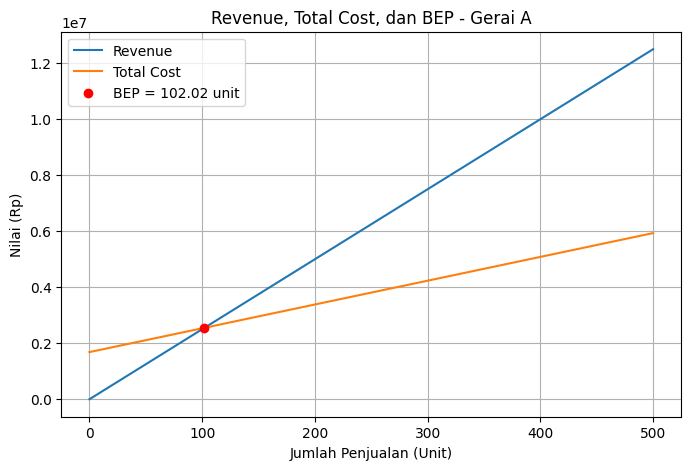

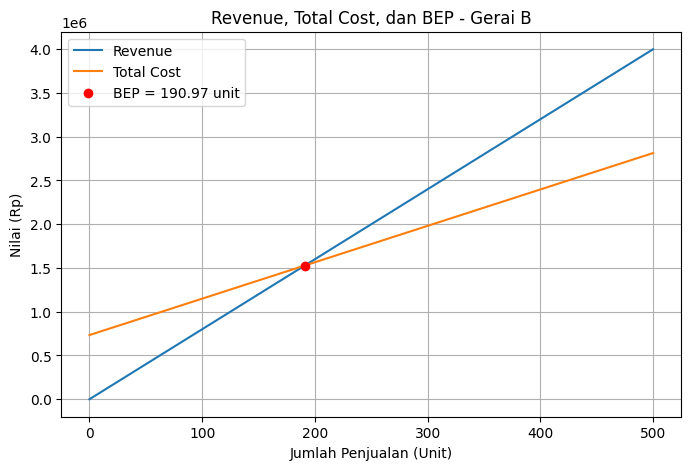

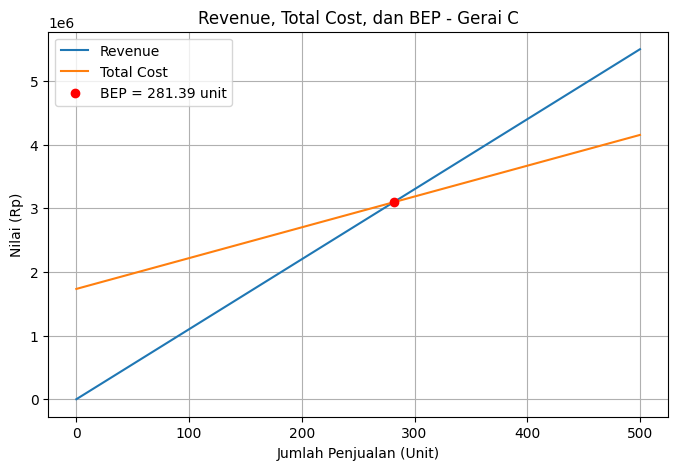

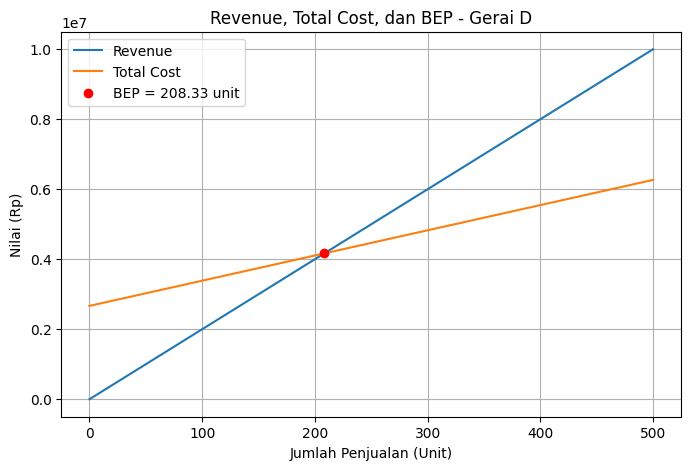

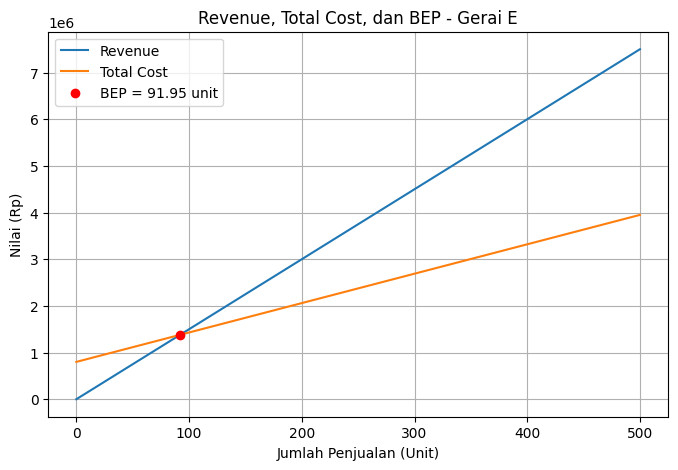

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Looping untuk membuat grafik masing-masing gerai
for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    # Mengambil parameter harga dan fixed cost
    harga = data["Harga Jual (Rp)"].iloc[0]
    fixed = data["Fixed Cost Harian (Rp)"].iloc[0]

    # Menghitung rata-rata biaya variabel per unit
    vc_per_unit = (
        data["Biaya Variabel (Rp)"].sum()
        / data["Jumlah Terjual (Unit)"].sum()
    )

    # Membuat rentang sumbu X (Jumlah Penjualan) dari 0 hingga 500 unit
    # (Diubah menjadi 500 agar Gerai C yang BEP-nya 282 unit tetap terlihat jelas di tengah grafik)
    x = np.linspace(0, 500, 100)

    # Menghitung nilai sumbu Y (Revenue dan Total Cost)
    revenue = harga * x
    total_cost = vc_per_unit * x + fixed

    # Mengambil nilai BEP dari tabel hasil_bep_df yang sudah dihitung di tahap sebelumnya
    bep = hasil_bep_df[
        hasil_bep_df["Gerai"] == gerai
    ]["BEP (Unit)"].iloc[0]

    # === Proses Plotting Grafik ===
    plt.figure(figsize=(8, 5))

    # Menggambar garis Revenue dan Total Cost
    plt.plot(x, revenue, label="Revenue", color='#1f77b4') # Garis Biru
    plt.plot(x, total_cost, label="Total Cost", color='#ff7f0e') # Garis Oranye

    # Menandai Titik Potong (BEP)
    plt.scatter(
        bep,
        harga * bep,
        color='red',
        zorder=5,
        label=f"BEP = {bep:.2f} unit"
    )

    # Format Tampilan Grafik
    plt.xlabel("Jumlah Penjualan (Unit)")
    plt.ylabel("Nilai (Rp)")
    plt.title(f"Revenue, Total Cost, dan BEP - {gerai}")
    plt.legend()
    plt.grid(True)
    plt.show()

**Analisis Grafik Break-Even Point (BEP) per Gerai**

Grafik di atas memvisualisasikan perjalanan tiap gerai menuju titik impas atau balik modal:

Garis Biru adalah Uang Masuk (Revenue), Garis Oranye adalah Total Pengeluaran (Biaya Tetap + Biaya Variabel), dan Titik Merah adalah letak persis di mana gerai tersebut mencapai Break-Even Point (BEP).

1. **Gerai A (Premium Gourmet)**: Garis biru menanjak dengan sangat curam, menunjukkan bahwa harga jual donat per pcs di gerai ini mahal. Namun, garis oranye (pengeluaran) juga dimulai dari titik yang lumayan tinggi, artinya modal mereka pun tinggi, karena mereka menyewa tempat kafe yang bagus. Titik potong merah menunjukkan angka BEP di 102.02 unit.  Kesimpulannya, strategi jualan harga mahal ini terbukti efektif. Gerai A tidak perlu memproduksi ribuan donat dalam jumlah banyak, mereka cukup menjual sekitar 103 donat sehari untuk menutup seluruh biaya sewa kafe dan mendapat keuntungan.

2. **Gerai B (Mass Market Volume)**: Garis biru di gerai ini lebih landai dibandingkan Gerai A. Ini karena harga donatnya murah, sehingga uang yang masuk dari tiap donat lebih sedikit. Namun, modal awal mereka (titik awal garis oranye) lebih rendah. Titik potong merah berada di angka 190.97 unit
Kesimpulannya, karena untung per donatnya tipis (harga donat murah), Gerai B harus mengandalkan kuantitas. Mereka harus menjual minimal 191 donat setiap harinya agar tidak rugi. Strategi ini cocok jika lokasi gerai berada di tempat yang sangat ramai pembeli.
  
  3. **Gerai C (Promo Agresif)**: Ini adalah grafik dengan titik temu paling jauh. Titik merah BEP berada di angka 281.39 unit. Garis oranye menyusul sangat lama karena biaya promosi dan diskon yang menekan margin keuntungan mereka.   Kesimpulannya, Gerai C memiliki beban target penjualan harian yang paling berat. Mereka harus menjual 282 donat setiap hari sekadar untuk bisa balik modal/tidak tugi. Strategi bakar uang dengan promo agresif ini sangat berisiko tinggi jika volume penjualan harian tiba-tiba sepi.
  
  4. **Gerai D (Mall Premium Flagship)**: Garis oranye (pengeluaran/modal) pada Gerai D dimulai dari titik yang paling tinggi di sumbu Y dibandingkan semua gerai lainnya. Ini menandakan bahwa gerai D memiliki beban sewa mall yang sangat mahal. Titik potong merah tercapai pada angka 208.33 unit.   Kesimpulannya, walaupun donat mereka dijual dengan harga mahal (terlihat dari garis biru yang curam), beban biaya sewa mall yang besar membuat mereka tetap harus mengejar target penjualan yang tinggi, yaitu 209 donat per hari. Jika mal sedang sepi pengunjung, gerai ini akan cepat mengalami kerugian besar.
  
  5. **Gerai E (Cloud Kitchen)**: Garis oranye dimulai dari titik yang sangat rendah, paling rendah di antara yang lain. Ini karena model cloud kitchen tidak butuh sewa tempat makan fisik atau pelayan. Titik merah tercapai sangat cepat di angka 91.95 unit.   Kesimpulannya, Gerai E adalah bisnis dengan risiko kebangkrutan harian paling kecil. Cukup hanya menjual 92 donat per hari lewat aplikasi online, mereka sudah berhasil balik modal. Ini menunjukkan efisiensi operasional yang sangat baik.